**TAISS 2026 - Filière F1 (Data Science)**

**TP2 - Segmentation RFM**

**Partie 4 : Caractérisation des segments**

**Entrée :** `../data/processed/clusters.parquet` (CustomerID, cluster, RFM en unités réelles)

**Sortie :** `../data/processed/segments_nommes.parquet` — la table client enrichie d'un libellé
métier par segment, prête pour une équipe marketing.

**Objectif :** transformer des numéros de cluster en profils client interprétables et actionnables.
Un clustering réussi mais mal caractérisé ne sert à rien à l'équipe qui doit l'utiliser.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from scipy.stats import kruskal, f_oneway

PROC = Path("../data/processed")
FIG = Path("../figures")
FIG.mkdir(parents=True, exist_ok=True)

clusters = pd.read_parquet(PROC / "clusters.parquet")
print("Shape :", clusters.shape)
display(clusters.head())

Shape : (5878, 13)


,CustomerID,cluster,Recence,Frequence,Montant,Anciennete,NbArticles,PanierMoyen,R_score,F_score,M_score,RFM_score,RFM_somme
0,12346,2,326,12,77556.46,726,74285,6463.038333,2,5,5,255,12
1,12347,2,2,8,4921.53,404,2967,615.191250,5,4,5,545,14
2,12348,3,75,5,2019.40,438,2714,403.880000,3,4,4,344,11
3,12349,1,19,4,4428.69,589,1624,1107.172500,5,3,5,535,13
4,12350,0,310,1,334.40,310,197,334.400000,2,1,2,212,5


## 1. Taille et poids économique des segments

In [2]:
resume = clusters.groupby("cluster").agg(
    n_clients=("CustomerID", "count"),
    ca_total=("Montant", "sum"),
).reset_index()
resume["part_clients"] = resume.n_clients / resume.n_clients.sum()
resume["part_ca"] = resume.ca_total / resume.ca_total.sum()
resume = resume.sort_values("part_ca", ascending=False)

display(resume.style.format({
    "ca_total": "{:,.0f}",
    "part_clients": "{:.1%}",
    "part_ca": "{:.1%}",
}))

,cluster,n_clients,ca_total,part_clients,part_ca
2,2,1196,"12,834,471",20.3%,73.9%
3,3,1459,"2,842,867",24.8%,16.4%
1,1,1250,"1,071,864",21.3%,6.2%
0,0,1973,"625,602",33.6%,3.6%


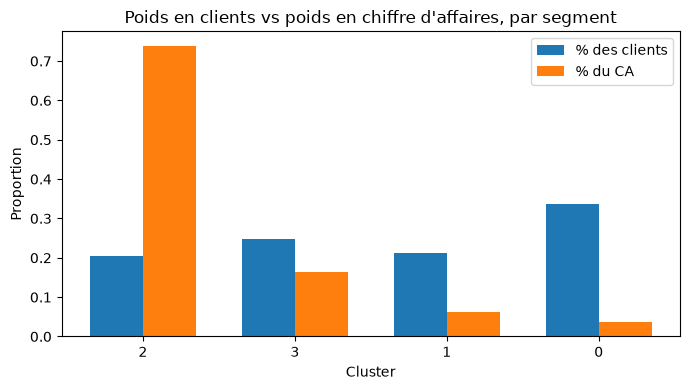

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(resume))
width = 0.35
ax.bar(x - width/2, resume.part_clients, width, label="% des clients")
ax.bar(x + width/2, resume.part_ca, width, label="% du CA")
ax.set_xticks(x)
ax.set_xticklabels(resume.cluster)
ax.set_xlabel("Cluster")
ax.set_ylabel("Proportion")
ax.set_title("Poids en clients vs poids en chiffre d'affaires, par segment")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "segments_poids_ca.png", dpi=120)
plt.show()

> **Lecture attendue :** si un segment concentre une part du CA nettement supérieure à sa part de
> clients, c'est un signal fort de segment prioritaire (peu de clients, beaucoup de valeur) — à
> confirmer avec les profils RFM ci-dessous avant de le déclarer "Champions".

## 2. Profils RFM par segment (unités réelles)

In [4]:
RFM3 = ["Recence", "Frequence", "Montant"]

profils = clusters.groupby("cluster")[RFM3].agg(["mean", "median"]).round(1)
display(profils)

Recence        Frequence         Montant        
           mean median      mean median     mean  median
cluster                                                 
0         394.9  402.0       1.4    1.0    317.1   273.3
1          28.3   24.0       3.1    3.0    857.5   734.1
2          27.7   17.0      19.3   13.0  10731.2  4986.1
3         230.1  186.0       5.1    4.0   1948.5  1450.0

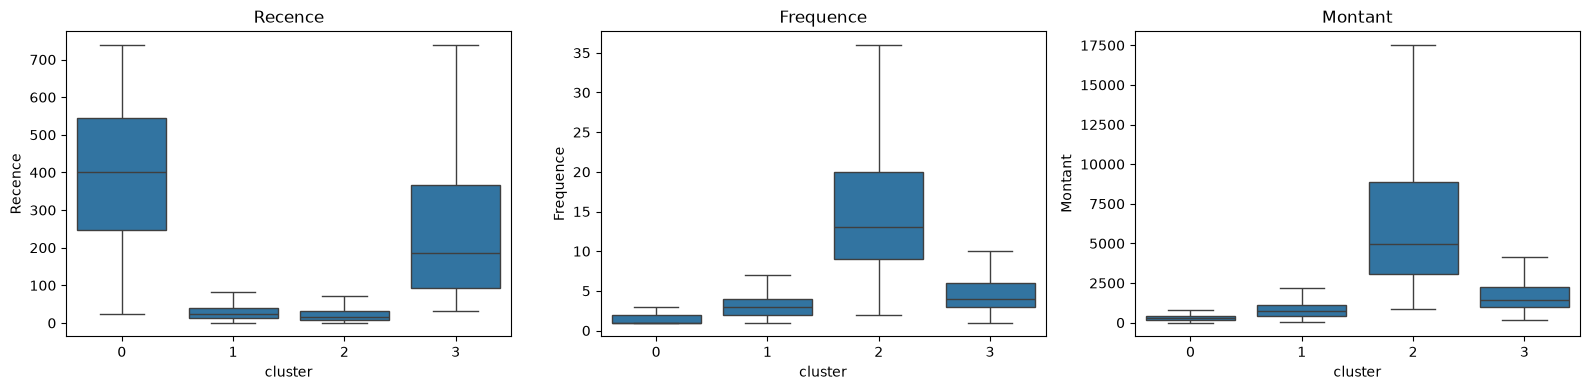

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, RFM3):
    sns.boxplot(data=clusters, x="cluster", y=col, ax=ax, showfliers=False)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIG / "segments_boxplots.png", dpi=120)
plt.show()

## 3. Les segments se distinguent-ils réellement ?

Un boxplot peut donner une impression de séparation qui ne résiste pas à un test statistique. On
utilise Kruskal-Wallis (non paramétrique, robuste aux distributions asymétriques typiques du
Montant et de la Fréquence) plutôt qu'ANOVA classique, avec ANOVA affichée en complément à titre de
comparaison.

In [6]:
tests = []
for col in RFM3:
    groupes = [g[col].values for _, g in clusters.groupby("cluster")]
    stat_kw, p_kw = kruskal(*groupes)
    stat_an, p_an = f_oneway(*groupes)
    tests.append({
        "variable": col,
        "kruskal_stat": round(stat_kw, 1), "kruskal_p": p_kw,
        "anova_stat": round(stat_an, 1), "anova_p": p_an,
    })

tests = pd.DataFrame(tests)
display(tests)

if (tests.kruskal_p < 0.05).all():
    print("Les 3 variables diffèrent significativement entre segments (p < 0.05) : "
          "la partition n'est pas un artefact du hasard.")
else:
    print("ATTENTION : au moins une variable ne distingue pas significativement les segments "
          "-> revoir le choix de k ou les features en Partie 3.")

,variable,kruskal_stat,kruskal_p,anova_stat,anova_p
0,Recence,4247.2,0.0,2672.4,0.000000e+00
1,Frequence,4454.8,0.0,709.7,0.000000e+00
2,Montant,4436.4,0.0,160.8,3.447137e-100


Les 3 variables diffèrent significativement entre segments (p < 0.05) : la partition n'est pas un artefact du hasard.


## 4. Profil normalisé (radar) — comparer les segments entre eux

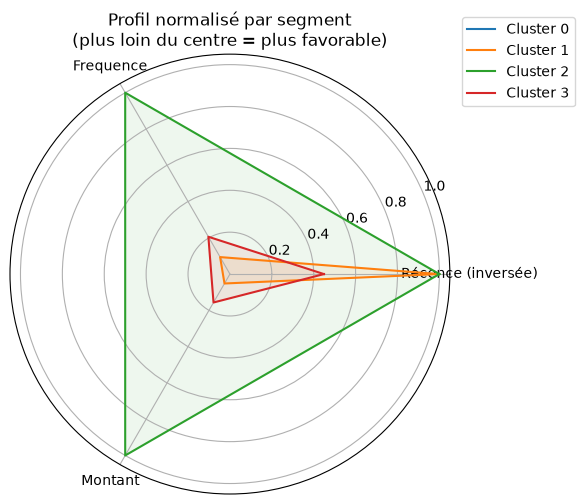

In [7]:
# Standardisation 0-1 (min-max) des moyennes par segment, uniquement pour la lecture visuelle du
# radar -- les tests statistiques ci-dessus, eux, portent sur les valeurs réelles.
moyennes = clusters.groupby("cluster")[RFM3].mean()
moyennes_norm = (moyennes - moyennes.min()) / (moyennes.max() - moyennes.min())
# Inverser la Récence normalisée : "proche de 1" doit vouloir dire "récent", pas "il y a longtemps"
moyennes_norm["Recence"] = 1 - moyennes_norm["Recence"]
moyennes_norm = moyennes_norm.rename(columns={"Recence": "Récence (inversée)"})

labels = moyennes_norm.columns.tolist()
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for cluster_id, row in moyennes_norm.iterrows():
    valeurs = row.tolist() + row.tolist()[:1]
    ax.plot(angles, valeurs, label=f"Cluster {cluster_id}")
    ax.fill(angles, valeurs, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Profil normalisé par segment\n(plus loin du centre = plus favorable)")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(FIG / "segments_radar.png", dpi=120)
plt.show()

## 5. Nommer les segments

Règle de nommage basée sur la position de chaque segment par rapport à la **médiane globale** sur
chacun des 3 axes (Récence faible = bon signe, Fréquence et Montant élevés = bon signe).

In [8]:
med_r, med_f, med_m = clusters.Recence.median(), clusters.Frequence.median(), clusters.Montant.median()

def nommer_segment(row):
    recent = row["Recence"] <= med_r
    frequent = row["Frequence"] >= med_f
    gros_montant = row["Montant"] >= med_m

    if recent and frequent and gros_montant:
        return "Champions"
    if recent and frequent and not gros_montant:
        return "Fidèles à faible valeur"
    if recent and not frequent and gros_montant:
        return "Nouveaux à fort potentiel"
    if recent and not frequent and not gros_montant:
        return "Nouveaux / à convertir"
    if not recent and frequent and gros_montant:
        return "À risque (forte valeur)"
    if not recent and frequent and not gros_montant:
        return "À risque (valeur modeste)"
    if not recent and not frequent and gros_montant:
        return "Gros ponctuels endormis"
    return "Perdus"

noms = moyennes.apply(nommer_segment, axis=1)
print("Noms attribués par segment :")
display(noms)

Noms attribués par segment :


cluster
0                     Perdus
1    Fidèles à faible valeur
2                  Champions
3    À risque (forte valeur)
dtype: str

In [9]:
clusters["segment"] = clusters["cluster"].map(noms)

resume_final = clusters.groupby("segment").agg(
    n_clients=("CustomerID", "count"),
    ca_total=("Montant", "sum"),
    recence_mediane=("Recence", "median"),
    frequence_mediane=("Frequence", "median"),
    montant_median=("Montant", "median"),
).sort_values("ca_total", ascending=False)
resume_final["part_ca"] = resume_final.ca_total / resume_final.ca_total.sum()

display(resume_final.style.format({
    "ca_total": "{:,.0f}", "part_ca": "{:.1%}",
    "recence_mediane": "{:.0f}", "frequence_mediane": "{:.0f}", "montant_median": "{:.0f}",
}))

,n_clients,ca_total,recence_mediane,frequence_mediane,montant_median,part_ca
segment,,,,,,
Champions,1196,"12,834,471",17,13,4986,73.9%
À risque (forte valeur),1459,"2,842,867",186,4,1450,16.4%
Fidèles à faible valeur,1250,"1,071,864",24,3,734,6.2%
Perdus,1973,"625,602",402,1,273,3.6%


> **À adapter dans le rapport :** ces libellés sont une proposition par défaut basée sur des règles
> simples (médiane globale par axe). Si un segment ne correspond pas intuitivement à son nom une
> fois les chiffres sous les yeux, ajustez la règle ou renommez-le manuellement — le nom doit servir
> la lecture métier, pas l'inverse.

## 6. Pistes d'action par segment

In [10]:
actions = {
    "Champions": "Fidéliser (programme VIP, avant-premières) — ne pas sur-solliciter par des promos.",
    "Fidèles à faible valeur": "Upsell / cross-sell pour augmenter le panier moyen.",
    "Nouveaux à fort potentiel": "Accueillir et convertir en fréquence (2e achat rapide).",
    "Nouveaux / à convertir": "Relance de découverte, guider vers un 2e achat.",
    "À risque (forte valeur)": "Priorité haute : campagne de réactivation ciblée, contact direct.",
    "À risque (valeur modeste)": "Réactivation automatisée à faible coût (email).",
    "Gros ponctuels endormis": "Comprendre la cause de l'inactivité avant de solliciter.",
    "Perdus": "Coût de réactivation probablement > valeur attendue — exclure des campagnes actives.",
}

for seg in resume_final.index:
    print(f"- {seg} : {actions.get(seg, 'À définir')}")

- Champions : Fidéliser (programme VIP, avant-premières) — ne pas sur-solliciter par des promos.
- À risque (forte valeur) : Priorité haute : campagne de réactivation ciblée, contact direct.
- Fidèles à faible valeur : Upsell / cross-sell pour augmenter le panier moyen.
- Perdus : Coût de réactivation probablement > valeur attendue — exclure des campagnes actives.


## 7. Sauvegarde

In [11]:
clusters.to_parquet(PROC / "segments_nommes.parquet", index=False)
print("Sauvegardé :", PROC / "segments_nommes.parquet")
print("Shape :", clusters.shape)
display(clusters.head())

Sauvegardé : ../data/processed/segments_nommes.parquet
Shape : (5878, 14)


,CustomerID,cluster,Recence,Frequence,Montant,Anciennete,NbArticles,PanierMoyen,R_score,F_score,M_score,RFM_score,RFM_somme,segment
0,12346,2,326,12,77556.46,726,74285,6463.038333,2,5,5,255,12,Champions
1,12347,2,2,8,4921.53,404,2967,615.191250,5,4,5,545,14,Champions
2,12348,3,75,5,2019.40,438,2714,403.880000,3,4,4,344,11,À risque (forte valeur)
3,12349,1,19,4,4428.69,589,1624,1107.172500,5,3,5,535,13,Fidèles à faible valeur
4,12350,0,310,1,334.40,310,197,334.400000,2,1,2,212,5,Perdus


**Mini-résumé** : les segments issus du clustering (Partie 3) ont été validés statistiquement
(Kruskal-Wallis significatif sur les 3 axes), visualisés (boxplots + radar), nommés selon leur
position par rapport à la médiane globale, et associés à une piste d'action marketing concrète.
`segments_nommes.parquet` est la table finale livrable à une équipe métier.